# 라이브러리

In [1]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
import matplotlib as mpl

# 데이터 로딩 관련 라이브러리
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 그래프 고해상도로 변경
%config InlineBackend.figure_format = 'retina'

# 마이너스 기호를 '-'로 표현하도록 변경
mpl.rc('axes', unicode_minus=False)

# Dataset load

In [2]:
# 현재 노트북 기준으로 프로젝트 루트를 찾아서 data 폴더 경로 고정
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")

# okcupid 데이터셋 불러오기
dataset = pd.read_csv(os.path.join(DATA_PATH, "okcupid_profiles.csv"))

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   sex          59946 non-null  str    
 3   orientation  59946 non-null  str    
 4   body_type    54650 non-null  str    
 5   diet         35551 non-null  str    
 6   drinks       56961 non-null  str    
 7   drugs        45866 non-null  str    
 8   education    53318 non-null  str    
 9   ethnicity    54266 non-null  str    
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  str    
 13  last_online  59946 non-null  str    
 14  location     59946 non-null  str    
 15  offspring    24385 non-null  str    
 16  pets         40025 non-null  str    
 17  religion     39720 non-null  str    
 18  sign         48890 non-null  str    
 19  smokes       54

In [4]:
dataset.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN


# 학습 데이터 분석

## 이탈 의심자 (타겟) 분석

In [5]:
last_online_sort = dataset["last_online"].sort_values(ascending=False)
last_online_sort.head()

59873    2012-07-01-08-57
59819    2012-07-01-08-56
59842    2012-07-01-08-56
59838    2012-07-01-08-56
59826    2012-07-01-08-56
Name: last_online, dtype: str

In [6]:
# 기준 시각 개체 생성 (마지막 날짜)
criterion_date = pd.Timestamp("2012-07-01 09:00")

# 마지막 접속 시각 Timestamp 객체로 변환
# last_online은 결측치가 없음
TS_last_online = pd.to_datetime(
    dataset["last_online"],
    format="%Y-%m-%d-%H-%M"
)

# 30일 이상 미접속 여부 (1: 비활동 의심, 0: 그 외)
dataset["churn_suspect"] = (
    (criterion_date - TS_last_online) >= pd.Timedelta(days=30)
).astype(int)

# 75:25
dataset["churn_suspect"].value_counts() / len(dataset)

churn_suspect
0    0.742785
1    0.257215
Name: count, dtype: float64

## 학습 / 테스트 분리

In [7]:
from common.preprocessing import train_test_split_by_target

X_train, X_test, Y_train, Y_test = train_test_split_by_target(
    dataset, "churn_suspect"
)

train_last_online = X_train["last_online"]
X_train.drop(columns="last_online", inplace=True)
X_test.drop(columns="last_online", inplace=True)

## 수치형 데이터 분석

In [8]:
train_num = X_train.select_dtypes(include=np.number)
train_num.describe()
# 109살 할아버지도 이용하는 갓앱
# 신장이 1인치인 태아도 연애에 관심 있음
# 수익이 -1이여도 연애는 하고싶을 수 있지

,age,height,income
count,44959.000000,44958.000000,44959.000000
mean,32.340710,68.302393,20000.081185
std,9.472268,4.019770,97022.702617
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


In [9]:
train_str = X_train.select_dtypes(exclude=np.number)
train_str.iloc[:,:14].describe()
# last_online을 제외하면 범주형 데이터가 맞음.

,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,job,location,offspring,pets,religion
count,44959,44959,44959,40960,26610,42717,34350,39955,40658,38789,44959,18368,30027,29752
unique,5,2,3,12,18,6,3,32,201,21,176,15,15,45
top,single,m,straight,average,mostly anything,socially,never,graduated from college/university,white,other,"san francisco, california",doesn't have kids,likes dogs and likes cats,agnosticism
freq,41794,26912,38766,10906,12462,31343,28268,17996,24446,5743,23273,5737,11100,2018


In [10]:
train_str.iloc[:,14:].describe()
# essay는 사용자가 직접 글을 쓰는 것이니 unique가 많을 수밖에 없음.

,sign,smokes,speaks,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
count,36687,40800,44921,40844,39249,37718,36349,37021,36794,34555,35612,30516,35468
unique,48,5,6057,40769,38654,36557,32848,36928,36705,32772,34250,29581,34136
top,gemini and it&rsquo;s fun to think about,no,english,.,enjoying it.,listening,my smile,ask me,my family,my future,out with friends,ask me,you want to.
freq,1332,32895,16357,10,44,61,385,12,5,116,69,36,149


# Feature Extraction
- Data Preprocessing 포함

In [11]:
from common.feature_extraction import feature_extraction

# Train 데이터 분석 후 선정한 최종 feature 20개
X_train = feature_extraction(X_train)
X_test = feature_extraction(X_test)

In [12]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("feature list\n", X_train.columns)

X_train: (44959, 20)
X_test : (14987, 20)
feature list
 Index(['essay_count', 'profile_completeness', 'religion_type', 'edu_level',
       'wants_kids', 'has_kids', 'diet_type', 'drugs_level', 'job', 'height',
       'status', 'income', 'essay_total_words', 'smokes_level', 'diet_strict',
       'edu_status', 'age', 'has_kids_na', 'essay_avg_len', 'essay_len_std'],
      dtype='str')


In [13]:
# Cat Boost는 number 결측치를 자동으로 처리함
print("X_train 결측치:", X_train.select_dtypes(exclude=np.number).isnull().sum().sum())
print("X_test 결측치 :", X_test.select_dtypes(exclude=np.number).isnull().sum().sum())

X_train 결측치: 0
X_test 결측치 : 0


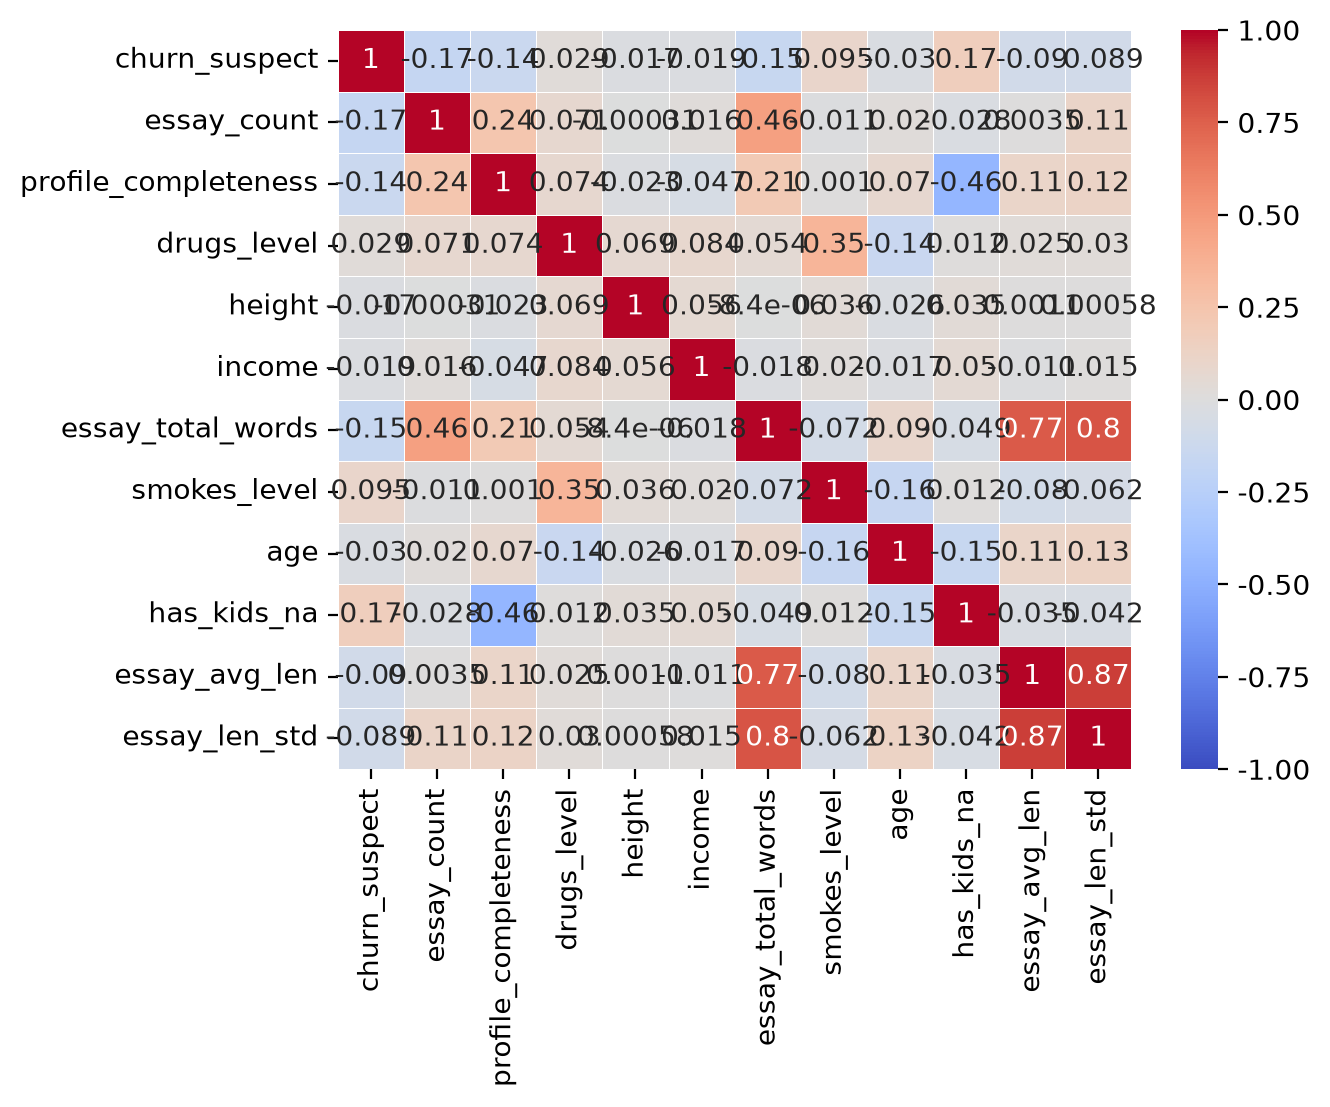

In [14]:
from common.show_graph import show_corr_map

train_num = X_train.select_dtypes(include=np.number)
show_corr_map(train_num, Y_train)

# Modeling

## Model 정의

In [15]:
X_train.dtypes.value_counts()

float64     9
int64       1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
int8        1
Name: count, dtype: int64

In [16]:
from common.meow_modeling import MeowModeling

# 최종 hyper parameter
cat_hp = {
    "iterations":300,
    "depth":5,
    "learning_rate":0.06,
    "auto_class_weights":"Balanced",   # fit 때 train 라벨로 자동 계산
}

meow = MeowModeling(X_train, Y_train, cat_hp=cat_hp)

## Random Search / Bayesian Search
- 스킵 권장.
- 탐색한 결과 Precision과 Recall을 같이 올릴 수 없어, 정밀 탐색이 유의미하지 않음.
- 기존 설정을 개선하는 후보를 찾지 못했으므로 기존 HP를 유지.

In [17]:
# 순차 탐색 결과: Random Search 12회 -> 상위 3개로 범위 축소 -> Bayesian Search 14회
# 각 탐색의 점수는 Train 내부 2-Fold AP, 최종 모델 비교는 Train 내부 5-Fold AP
random_best_hp = {'bootstrap_type': 'Bayesian',
 'iterations': 460,
 'depth': 4,
 'learning_rate': 0.0578200315113086,
 'l2_leaf_reg': 13.332914892873946,
 'random_strength': 0.0749305452093525,
 'class_weight_1': 2.649072184499764,
 'bagging_temperature': 1.8888778463576217}
bayesian_best_hp = {'bootstrap_type': 'Bayesian',
 'iterations': 420,
 'depth': 6,
 'learning_rate': 0.03673832834920366,
 'l2_leaf_reg': 17.29796389523008,
 'random_strength': 0.05244344181970254,
 'class_weight_1': 3.6372192454286574,
 'bagging_temperature': 1.1904161055128228}
refined_range = {'iterations': [400, 520],
 'depth': [3, 6],
 'learning_rate': [0.027239526799657902, 0.06489310549789905],
 'l2_leaf_reg': [1.7670678029139042, 17.354178073509846],
 'random_strength': [0.02, 0.32473777384731795],
 'class_weight_1': [2.43951844330164, 4.255650867018713],
 'bagging_temperature': [0.29073044675164095, 2.09733185500188]}

hpo_result = pd.DataFrame([{'모델': '기존 설정 (최종 유지)',
  'PR-AUC(AP)': 0.490913,
  'ROC-AUC': 0.737029,
  'Recall': 0.687565,
  'Precision': 0.408364,
  'F1': 0.512371,
  'Accuracy': 0.66336},
 {'모델': 'Random Search',
  'PR-AUC(AP)': 0.489408,
  'ROC-AUC': 0.736177,
  'Recall': 0.637063,
  'Precision': 0.41994,
  'F1': 0.506181,
  'Accuracy': 0.680264},
 {'모델': 'Bayesian 정밀 탐색',
  'PR-AUC(AP)': 0.490315,
  'ROC-AUC': 0.7367,
  'Recall': 0.7922,
  'Precision': 0.369541,
  'F1': 0.50398,
  'Accuracy': 0.598901}])


# 결과를 볼 것이라면 True로 변경
PRINT_RESULT = False

if PRINT_RESULT:
  print("Random 2-Fold AP  :", round(0.4860030180546533, 6))
  print("Bayesian 2-Fold AP:", round(0.48678630824016556, 6))
  print("Bayesian 탐색 범위:", refined_range)
  display(hpo_result.sort_values("PR-AUC(AP)", ascending=False))


In [18]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score, recall_score, precision_score, f1_score
from catboost import CatBoostClassifier

# 실행 시 Random 12회 -> 그 결과로 범위를 좁힌 Bayesian 14회 -> 5-Fold 비교
# 이미 실행한 결과는 위 셀에 저장. 재탐색하려면 True로 변경
RUN_HPO = False


cat_cols = X_train.select_dtypes(exclude=[np.number, "bool", "boolean"]).columns.tolist()

def make_hpo_catboost(hp):
    params = hp.copy()
    params["class_weights"] = [1.0, params.pop("class_weight_1")]
    return CatBoostClassifier(
        **params,
        cat_features=cat_cols,
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        thread_count=4
    )


# 1단계: 넓은 범위에서 Random Search
full_range = {
    "iterations": (180, 600),
    "depth": (3, 7),
    "learning_rate": (0.025, 0.13),
    "l2_leaf_reg": (0.7, 18.0),
    "random_strength": (0.02, 4.0),
    "class_weight_1": (1.5, 4.3),
    "bagging_temperature": (0.0, 2.5),
    "subsample": (0.65, 1.0),
}
log_keys = {"learning_rate", "l2_leaf_reg", "random_strength"}


def suggest_random(trial):
    bootstrap = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"])
    hp = {"bootstrap_type": bootstrap}
    for name in ["iterations", "depth", "learning_rate", "l2_leaf_reg", "random_strength", "class_weight_1"]:
        low, high = full_range[name]
        if name == "iterations":
            hp[name] = trial.suggest_int(name, low, high, step=20)
        elif name == "depth":
            hp[name] = trial.suggest_int(name, low, high)
        else:
            hp[name] = trial.suggest_float(name, low, high, log=name in log_keys)
    name = "bagging_temperature" if bootstrap == "Bayesian" else "subsample"
    hp[name] = trial.suggest_float(name, *full_range[name])
    return hp


def score_hp(hp, cv):
    scores = []
    for tr_idx, va_idx in cv.split(X_train, Y_train):
        model = make_hpo_catboost(hp)
        model.fit(X_train.iloc[tr_idx], Y_train.iloc[tr_idx])
        proba = model.predict_proba(X_train.iloc[va_idx])[:, 1]
        scores.append(average_precision_score(Y_train.iloc[va_idx], proba))
    return np.mean(scores)


# 2단계: 상위 Random 결과가 집중된 구간을 실제로 Bayesian 탐색에 전달
# 가장 좋은 bootstrap 안의 상위 3개로 최소/최대값을 구하고 약간의 여유를 둠
def narrow_range(random_study):
    trials = sorted(random_study.trials, key=lambda t: t.value, reverse=True)
    bootstrap = trials[0].params["bootstrap_type"]
    top = [t.params for t in trials if t.params["bootstrap_type"] == bootstrap][:3]
    assert len(top) >= 2, "상위 Random 후보가 부족하면 Random 탐색 횟수를 늘리세요."
    names = ["iterations", "depth", "learning_rate", "l2_leaf_reg", "random_strength", "class_weight_1"]
    names.append("bagging_temperature" if bootstrap == "Bayesian" else "subsample")
    narrowed = {}
    for name in names:
        low, high = full_range[name]
        values = np.array([hp[name] for hp in top])
        vmin, vmax = float(values.min()), float(values.max())
        if name in log_keys:
            a, b = np.log(low), np.log(high)
            c, d = np.log(vmin), np.log(vmax)
            margin = max(0.15 * (d - c), 0.07 * (b - a))
            bounds = (float(np.exp(max(a, c - margin))), float(np.exp(min(b, d + margin))))
        else:
            margin = max(0.15 * (vmax - vmin), 0.07 * (high - low))
            bounds = (max(low, vmin - margin), min(high, vmax + margin))
        if name == "iterations":
            bounds = (int(np.floor(bounds[0] / 20) * 20), int(np.ceil(bounds[1] / 20) * 20))
        elif name == "depth":
            bounds = (int(np.floor(bounds[0])), int(np.ceil(bounds[1])))
        narrowed[name] = bounds
    return bootstrap, top, narrowed


if RUN_HPO:
    search_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    random_study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.RandomSampler(seed=42)
    )
    random_study.optimize(lambda trial: score_hp(suggest_random(trial), search_cv), n_trials=12)

    bootstrap, top_random, narrowed = narrow_range(random_study)
    print("Random 최고 AP:", random_study.best_value)
    print("Random 최고 HP:", random_study.best_params)
    print("Bayesian 축소 범위:", narrowed)

    def suggest_bayesian(trial):
        hp = {"bootstrap_type": trial.suggest_categorical("bootstrap_type", [bootstrap])}
        for name, (low, high) in narrowed.items():
            if name == "iterations":
                hp[name] = trial.suggest_int(name, int(low), int(high), step=20)
            elif name == "depth":
                hp[name] = trial.suggest_int(name, int(low), int(high))
            else:
                hp[name] = trial.suggest_float(name, low, high, log=name in log_keys)
        return hp

    bayesian_study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=43, n_startup_trials=4)
    )
    # Random 상위 2개를 먼저 평가하고, 그 결과까지 활용해 이후 후보를 선정
    bayesian_study.enqueue_trial(top_random[0])
    bayesian_study.enqueue_trial(top_random[1])
    bayesian_study.optimize(lambda trial: score_hp(suggest_bayesian(trial), search_cv), n_trials=14)
    print("Bayesian 최고 AP:", bayesian_study.best_value)
    print("Bayesian 최고 HP:", bayesian_study.best_params)

    # 탐색에 쓰지 않은 Fold 수로 기존 설정과 함께 재검증 (X_test는 사용하지 않음)
    confirm_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    candidates = [
        ("기존 설정", meow.make_meow_model),
        ("Random Search", lambda: make_hpo_catboost(random_study.best_params)),
        ("Bayesian 정밀 탐색", lambda: make_hpo_catboost(bayesian_study.best_params)),
    ]
    rows = []
    for name, factory in candidates:
        fold_scores = []
        for tr_idx, va_idx in confirm_cv.split(X_train, Y_train):
            model = factory()
            model.fit(X_train.iloc[tr_idx], Y_train.iloc[tr_idx])
            proba = model.predict_proba(X_train.iloc[va_idx])[:, 1]
            pred = (proba >= 0.5).astype(int)
            y_va = Y_train.iloc[va_idx]
            fold_scores.append({
                "PR-AUC(AP)": average_precision_score(y_va, proba),
                "ROC-AUC": roc_auc_score(y_va, proba),
                "Recall": recall_score(y_va, pred),
                "Precision": precision_score(y_va, pred),
                "F1": f1_score(y_va, pred),
            })
        rows.append({"모델": name, **pd.DataFrame(fold_scores).mean().to_dict()})
    display(pd.DataFrame(rows).sort_values("PR-AUC(AP)", ascending=False))


## Cross Validation

In [19]:
meow.run_strat_kfold(5)

1번째 Stratified K-Fold: ROC-AUC=0.73888, PR-AUC=0.48506, F1=0.51367, Recall=0.68223, Precision=0.41190
2번째 Stratified K-Fold: ROC-AUC=0.74156, PR-AUC=0.49893, F1=0.51097, Recall=0.69477, Precision=0.40407
3번째 Stratified K-Fold: ROC-AUC=0.73430, PR-AUC=0.48825, F1=0.50825, Recall=0.67920, Precision=0.40605
4번째 Stratified K-Fold: ROC-AUC=0.73762, PR-AUC=0.48954, F1=0.51313, Recall=0.68007, Precision=0.41200
5번째 Stratified K-Fold: ROC-AUC=0.73210, PR-AUC=0.48723, F1=0.50697, Recall=0.68426, Precision=0.40265
--------------------------------------------------
5-Fold 평균
 ROC-AUC      0.73689
PR-AUC       0.48980
F1           0.51060
Recall       0.68411
Precision    0.40733
dtype: float64
5-Fold 표준편차
 ROC-AUC      0.00374
PR-AUC       0.00536
F1           0.00294
Recall       0.00628
Precision    0.00438
dtype: float64


# Evaluation

## 평가

In [20]:
meow.fit_evaluation(X_test, Y_test)

Train Accuracy : 0.67206
Valid Accuracy : 0.66471
Precision      : 0.41028
Recall         : 0.69390
F1-score       : 0.51566
ROC-AUC        : 0.74005
PR-AUC         : 0.48525
Overall Score  : 0.56903


In [21]:
meow_model = meow.get_model()
test_pred, test_proba = meow.get_test_pred_proba()

## Confusion matrix

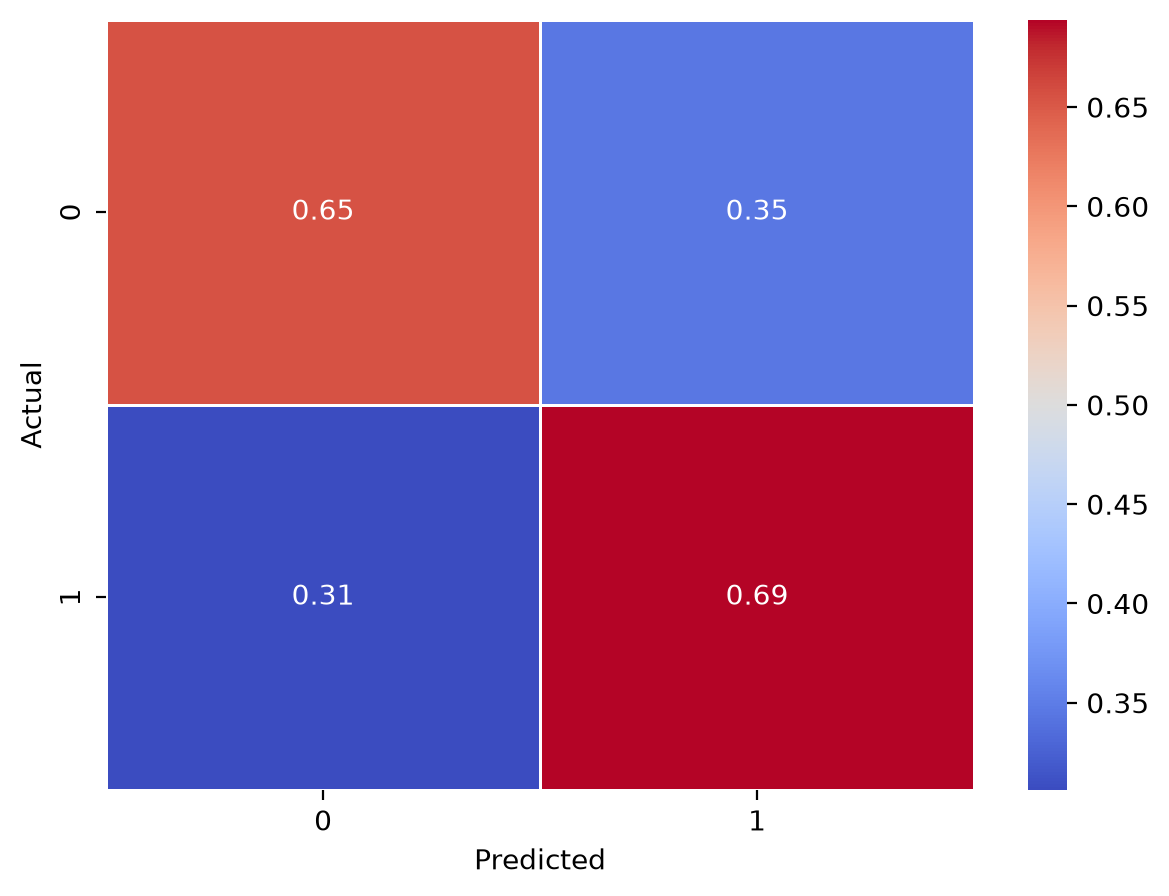

In [22]:
from common.evaluation_plots import show_norm_conf_mx

show_norm_conf_mx(y=Y_test, pred=test_pred)

## ROC Curve

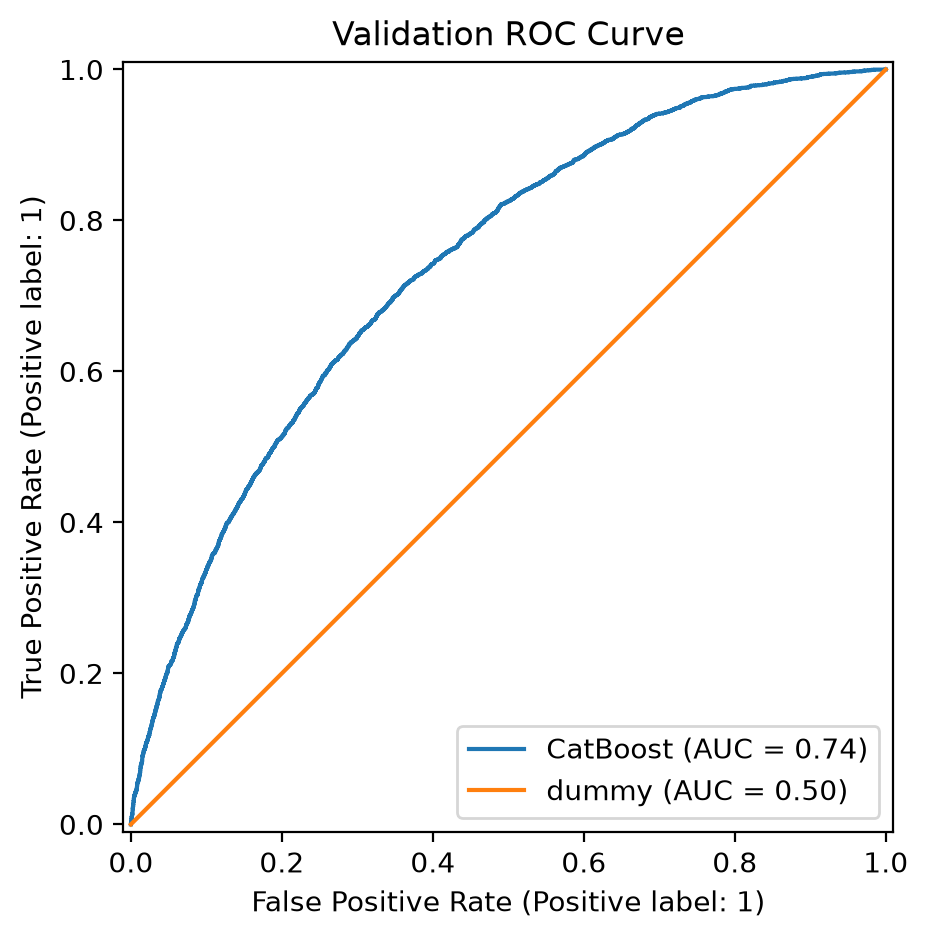

In [23]:
from common.evaluation_plots import show_roc_curve, show_pr_curve

show_roc_curve(X_train, Y_train, X_test, Y_test, test_proba)

## PR Curve

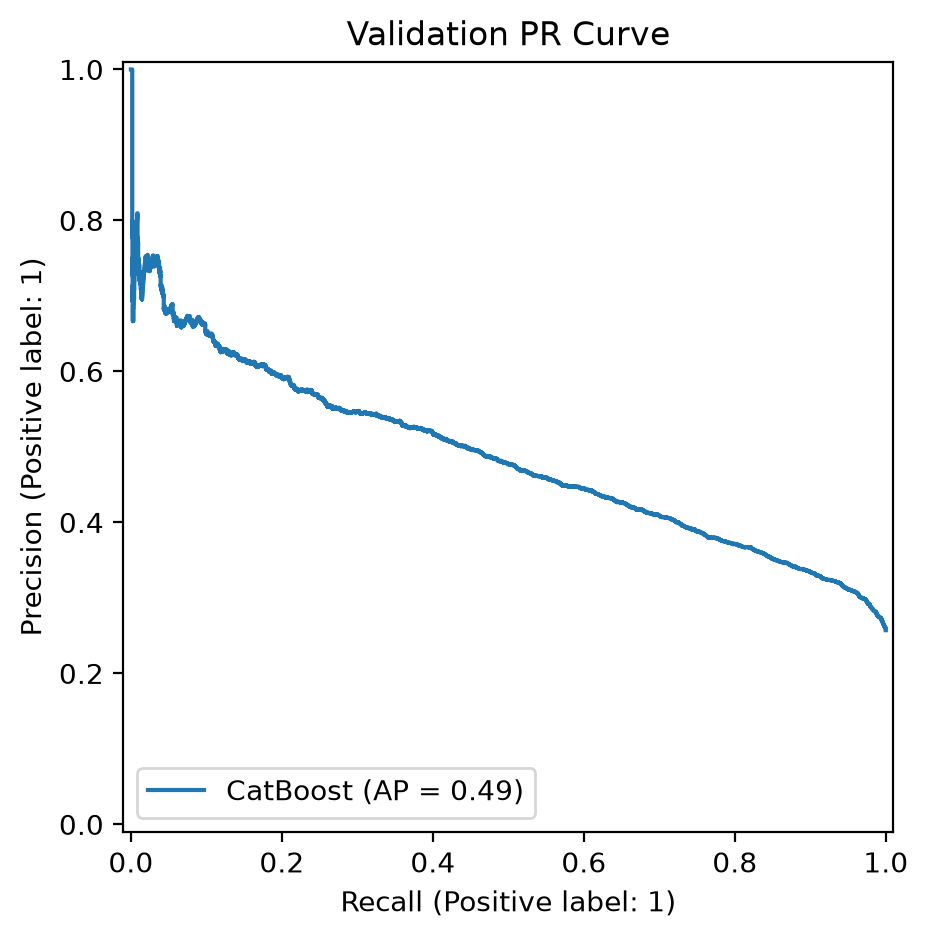

In [24]:
show_pr_curve(Y_test, test_proba)

## XAI (SHAP)

In [25]:
from common.shap_plots import ShapAnalyzer

meow_shap = ShapAnalyzer(X_test, meow_model)

c:\dev\project\SKN36-2st-3team\common\shap_plots.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


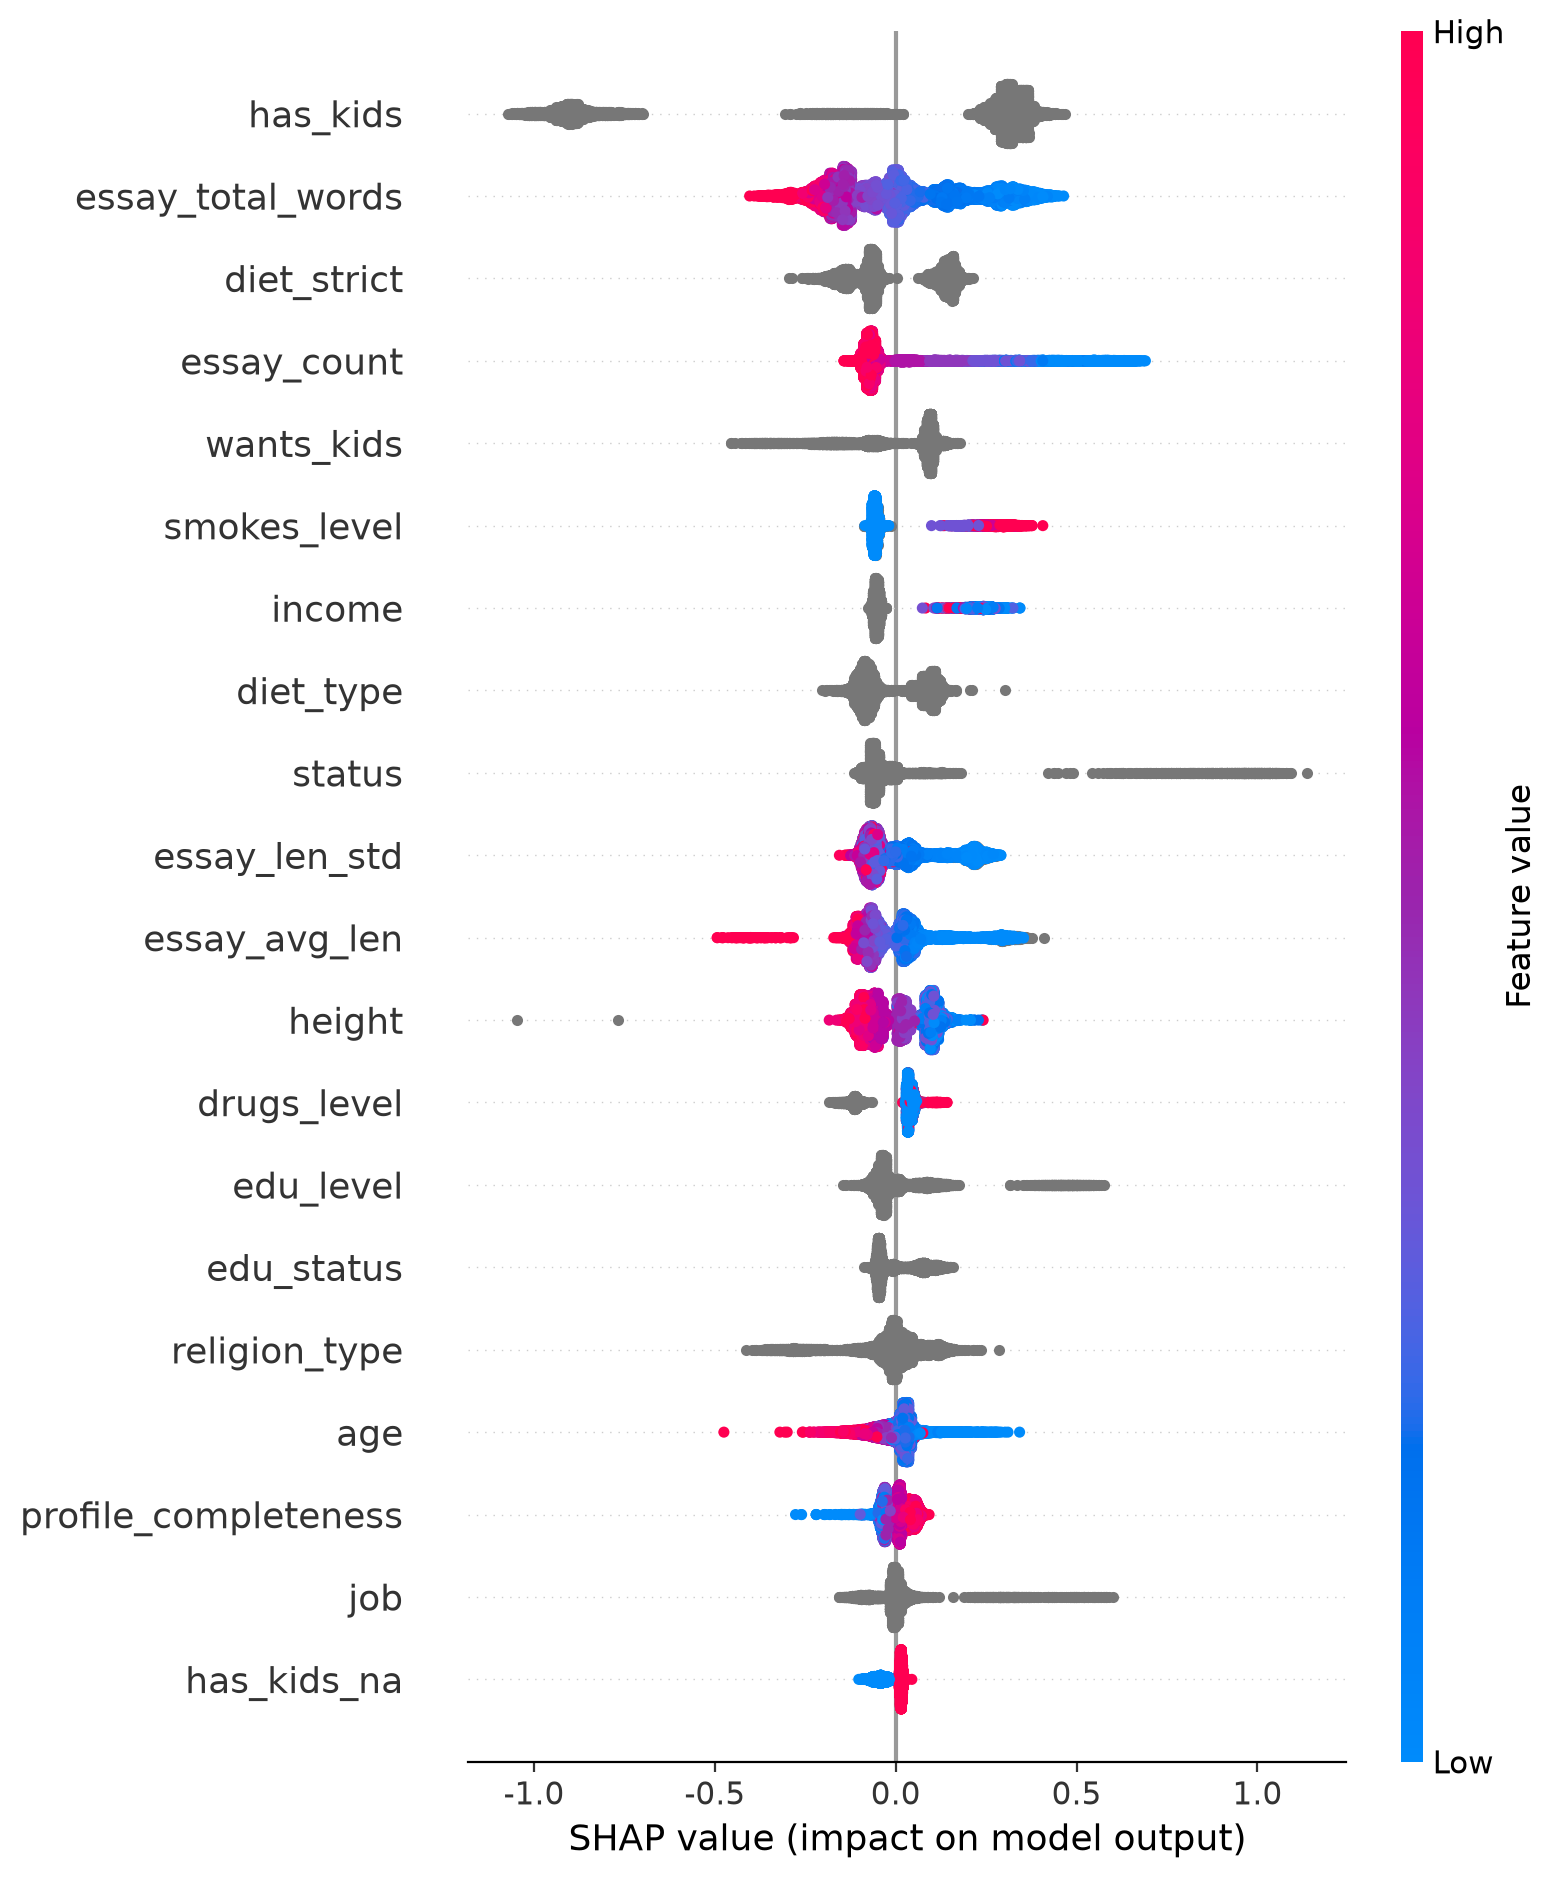

In [26]:
meow_shap.show_summary()

c:\dev\project\SKN36-2st-3team\common\shap_plots.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(self.shap_values, self.X_test, plot_type="bar")


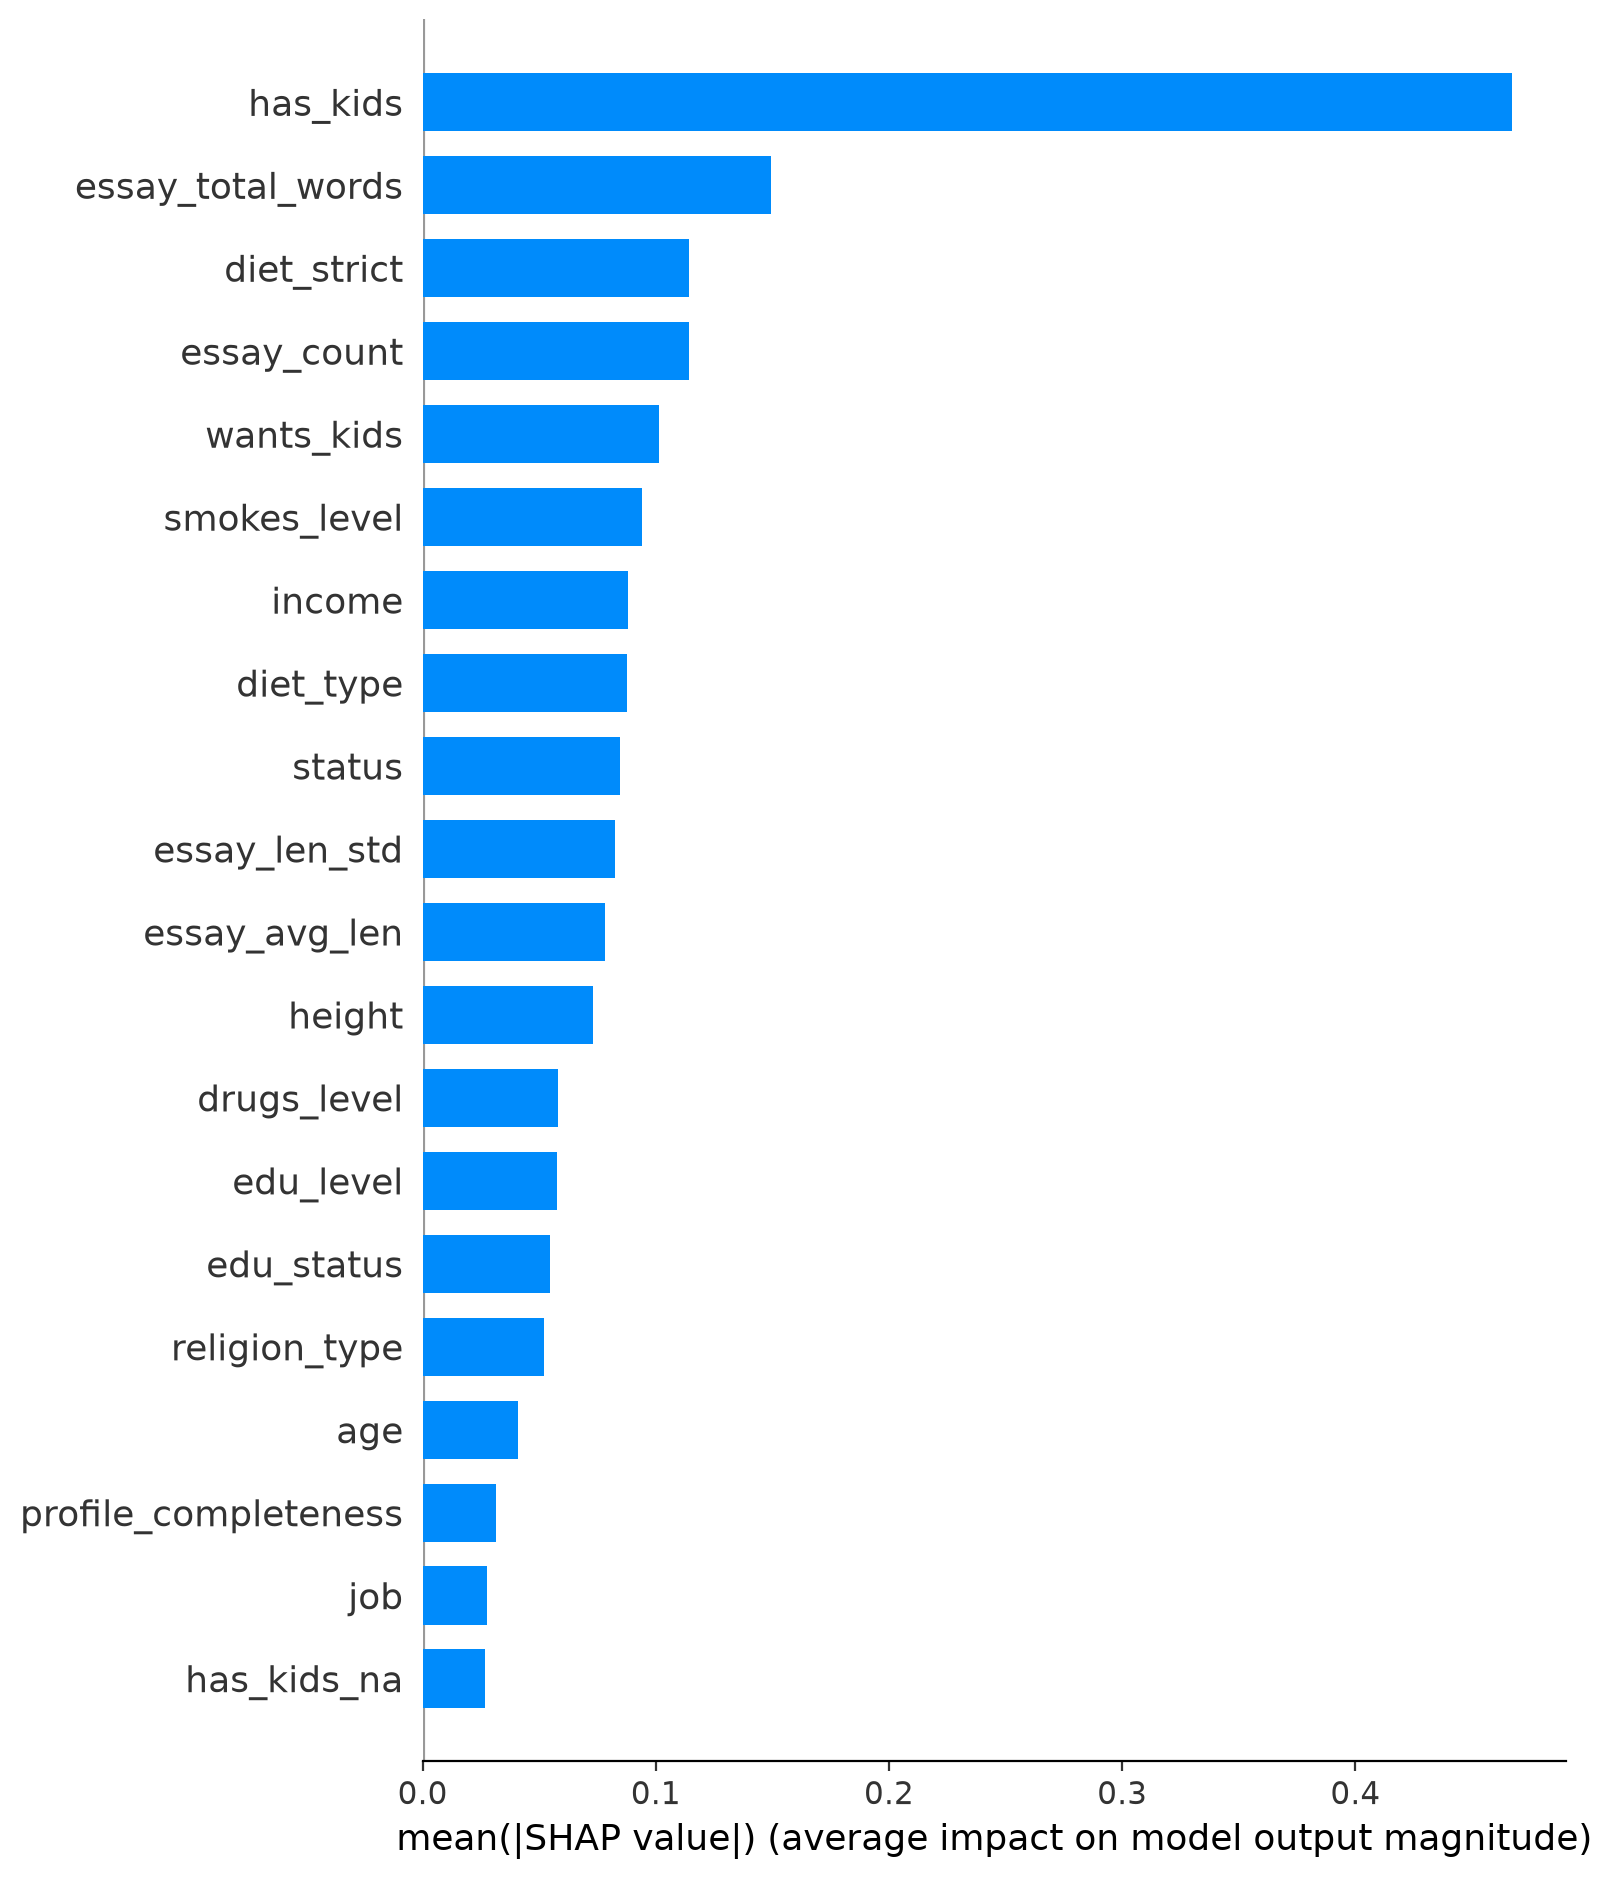

In [27]:
meow_shap.show_summary(plot_bar=True)

In [28]:
meow_shap.get_mean_abs(30)

,feature,mean_abs_shap
5,has_kids,0.466965
12,essay_total_words,0.149399
14,diet_strict,0.114385
0,essay_count,0.114320
4,wants_kids,0.101465
13,smokes_level,0.094068
11,income,0.088273
6,diet_type,0.087827
10,status,0.084759
19,essay_len_std,0.082276


c:\dev\project\SKN36-2st-3team\common\shap_plots.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


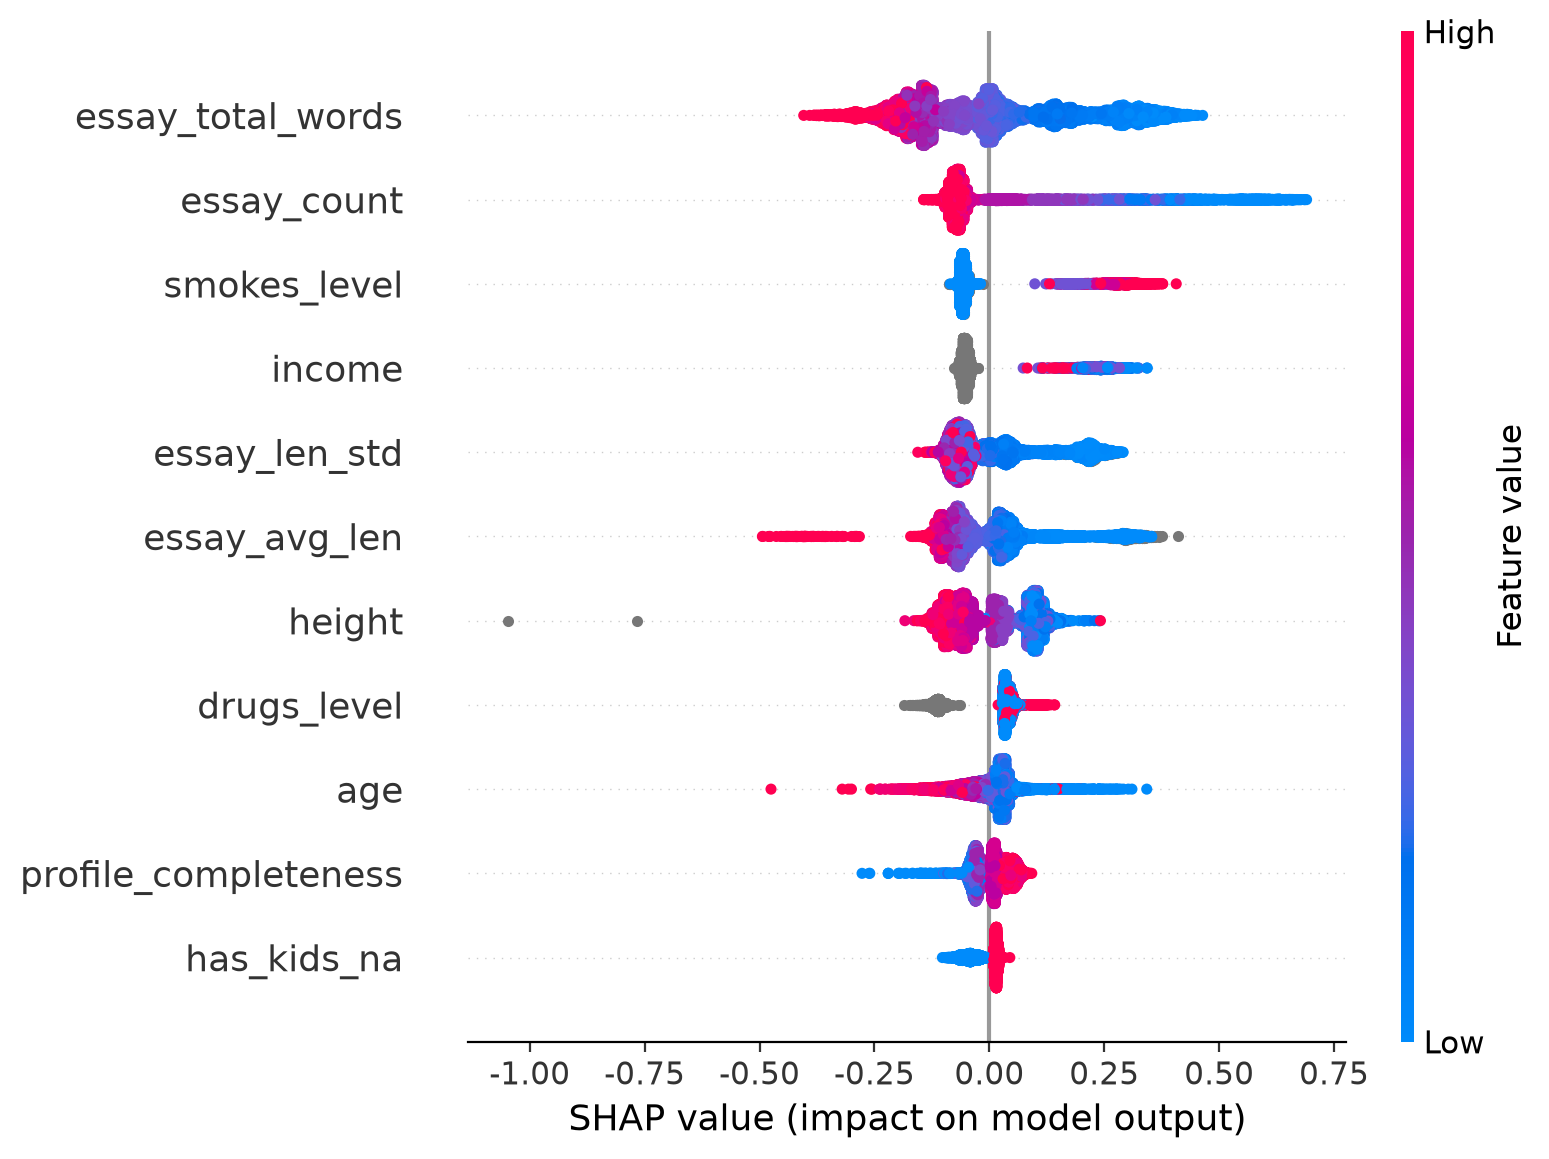

In [29]:
# 수치형 feature만 보기
meow_shap.show_summary("num")

c:\dev\project\SKN36-2st-3team\common\shap_plots.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


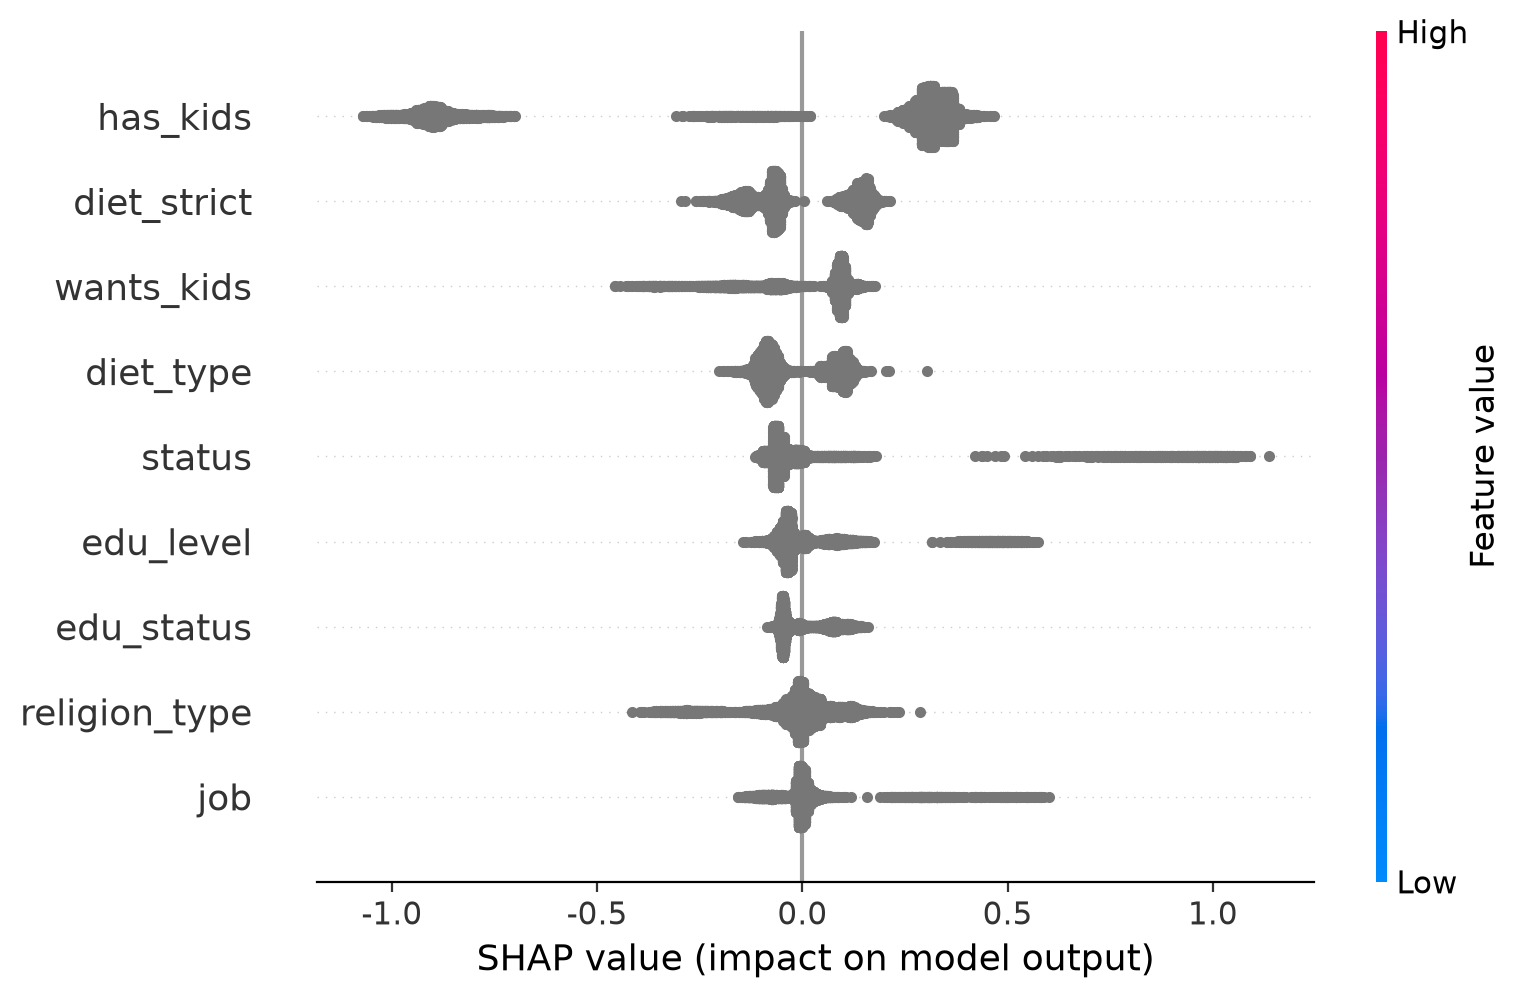

In [30]:
# 범주형 feature만 보기
meow_shap.show_summary("str")

# 모델 저장

In [31]:
from datetime import datetime
from pathlib import Path

# 진짜 저장할거야? 진짜?
# 진짜루??????
answer = input("모델을 저장하려면 'Y'를 눌러주세요: ")

if answer.upper() == "Y":
    # 저장 폴더 생성
    Path("models").mkdir(parents=True, exist_ok=True)

    # 현재 시각으로 파일명 생성
    timestamp = datetime.now().strftime("%m_%d_%H_%M")
    model_path = f"models/okcupid_model_{timestamp}.cbm"

    # 모델 저장
    meow_model.save_model(model_path)
    print(f"저장 완료: {model_path}")


# # 로드는 아래와 같이 해주세요.
# model = CatBoostClassifier()
# model.load_model("models/okcupid_model_09_19_18_56.cbm")

저장 완료: models/okcupid_model_09_21_18_00.cbm
